[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv10 Object Detection on a Custom Dataset

---

[![arXiv](https://img.shields.io/badge/arXiv-2405.14458-b31b1b.svg)](https://arxiv.org/pdf/2405.14458.pdf)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/THU-MIG/yolov10)
[![Hugging Face Spaces](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/YOLO-ARENA)

YOLOv10 is a new generation in the YOLO series for real-time end-to-end object detection. It aims to improve both the performance and efficiency of YOLOs by eliminating the need for non-maximum suppression (NMS) and optimizing model architecture comprehensively. This advancement reduces computational overhead, enhancing both efficiency and capability. YOLOv10 shows state-of-the-art performance and efficiency, with YOLOv10-S being 1.8 times faster than RT-DETR-R18 and having significantly fewer parameters and FLOPs. Additionally, YOLOv10-B demonstrates 46% less latency and 25% fewer parameters compared to YOLOv9-C while maintaining the same performance.

<p align="center">
  <img src="https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov10_latency.svg" width=48%>
  <img src="https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov10_params.svg" width=48%> <br>
  Comparisons with others in terms of latency-accuracy (left) and size-accuracy (right) trade-offs.
</p>

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv10
- Download pre-trained weights
- Download example data
- Inference with Pre-trained COCO Model
- Download dataset from Roboflow Universe
- Custom Training
- Validate Custom Model
- Inference with Custom Model

**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Nov 25 04:15:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install YOLOv11

**NOTE:** Currently, YOLOv10 does not have its own PyPI package. Therefore, we need to install the code from the source.

In [4]:
%pip install ultralytics supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 38.3/235.7 GB disk)


**NOTE:** We will also install two additional packages: [`roboflow`](https://github.com/roboflow/roboflow-python) to download the dataset from [Roboflow Universe](https://universe.roboflow.com/), which we will use to train our model, and [`supervision`](https://github.com/roboflow/supervision), which we will use for visualizing the results.

In [ ]:
!pip install -q supervision roboflow

## Download dataset from Roboflow Universe

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NSxfWtaoM32ekhgU480Y")
project = rf.workspace("geethachandrashekar29-gmail-com").project("spinal_cord")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Spinal_cord-2 in yolov11:: 100%|██████████| 9937/9937 [00:01<00:00, 8922.73it/s]


**NOTE:**
Make sure the last 4 lines of the data.yaml file have the following format:

```
test: ../test/images
train: ../train/images
val: ../valid/images
```

If using a dataset from Roboflow, run the command below. 👇🏻

In [ ]:
!pip install albumentations==1.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train epochs=100 batch=32 plots=True \
model=yolo11n.pt \
data={dataset.location}/data.yaml

/content
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-80GB, 81222MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Spinal_cord-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch9810.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch9811.jpg  weights
labels.jpg			 train_batch9812.jpg


/content


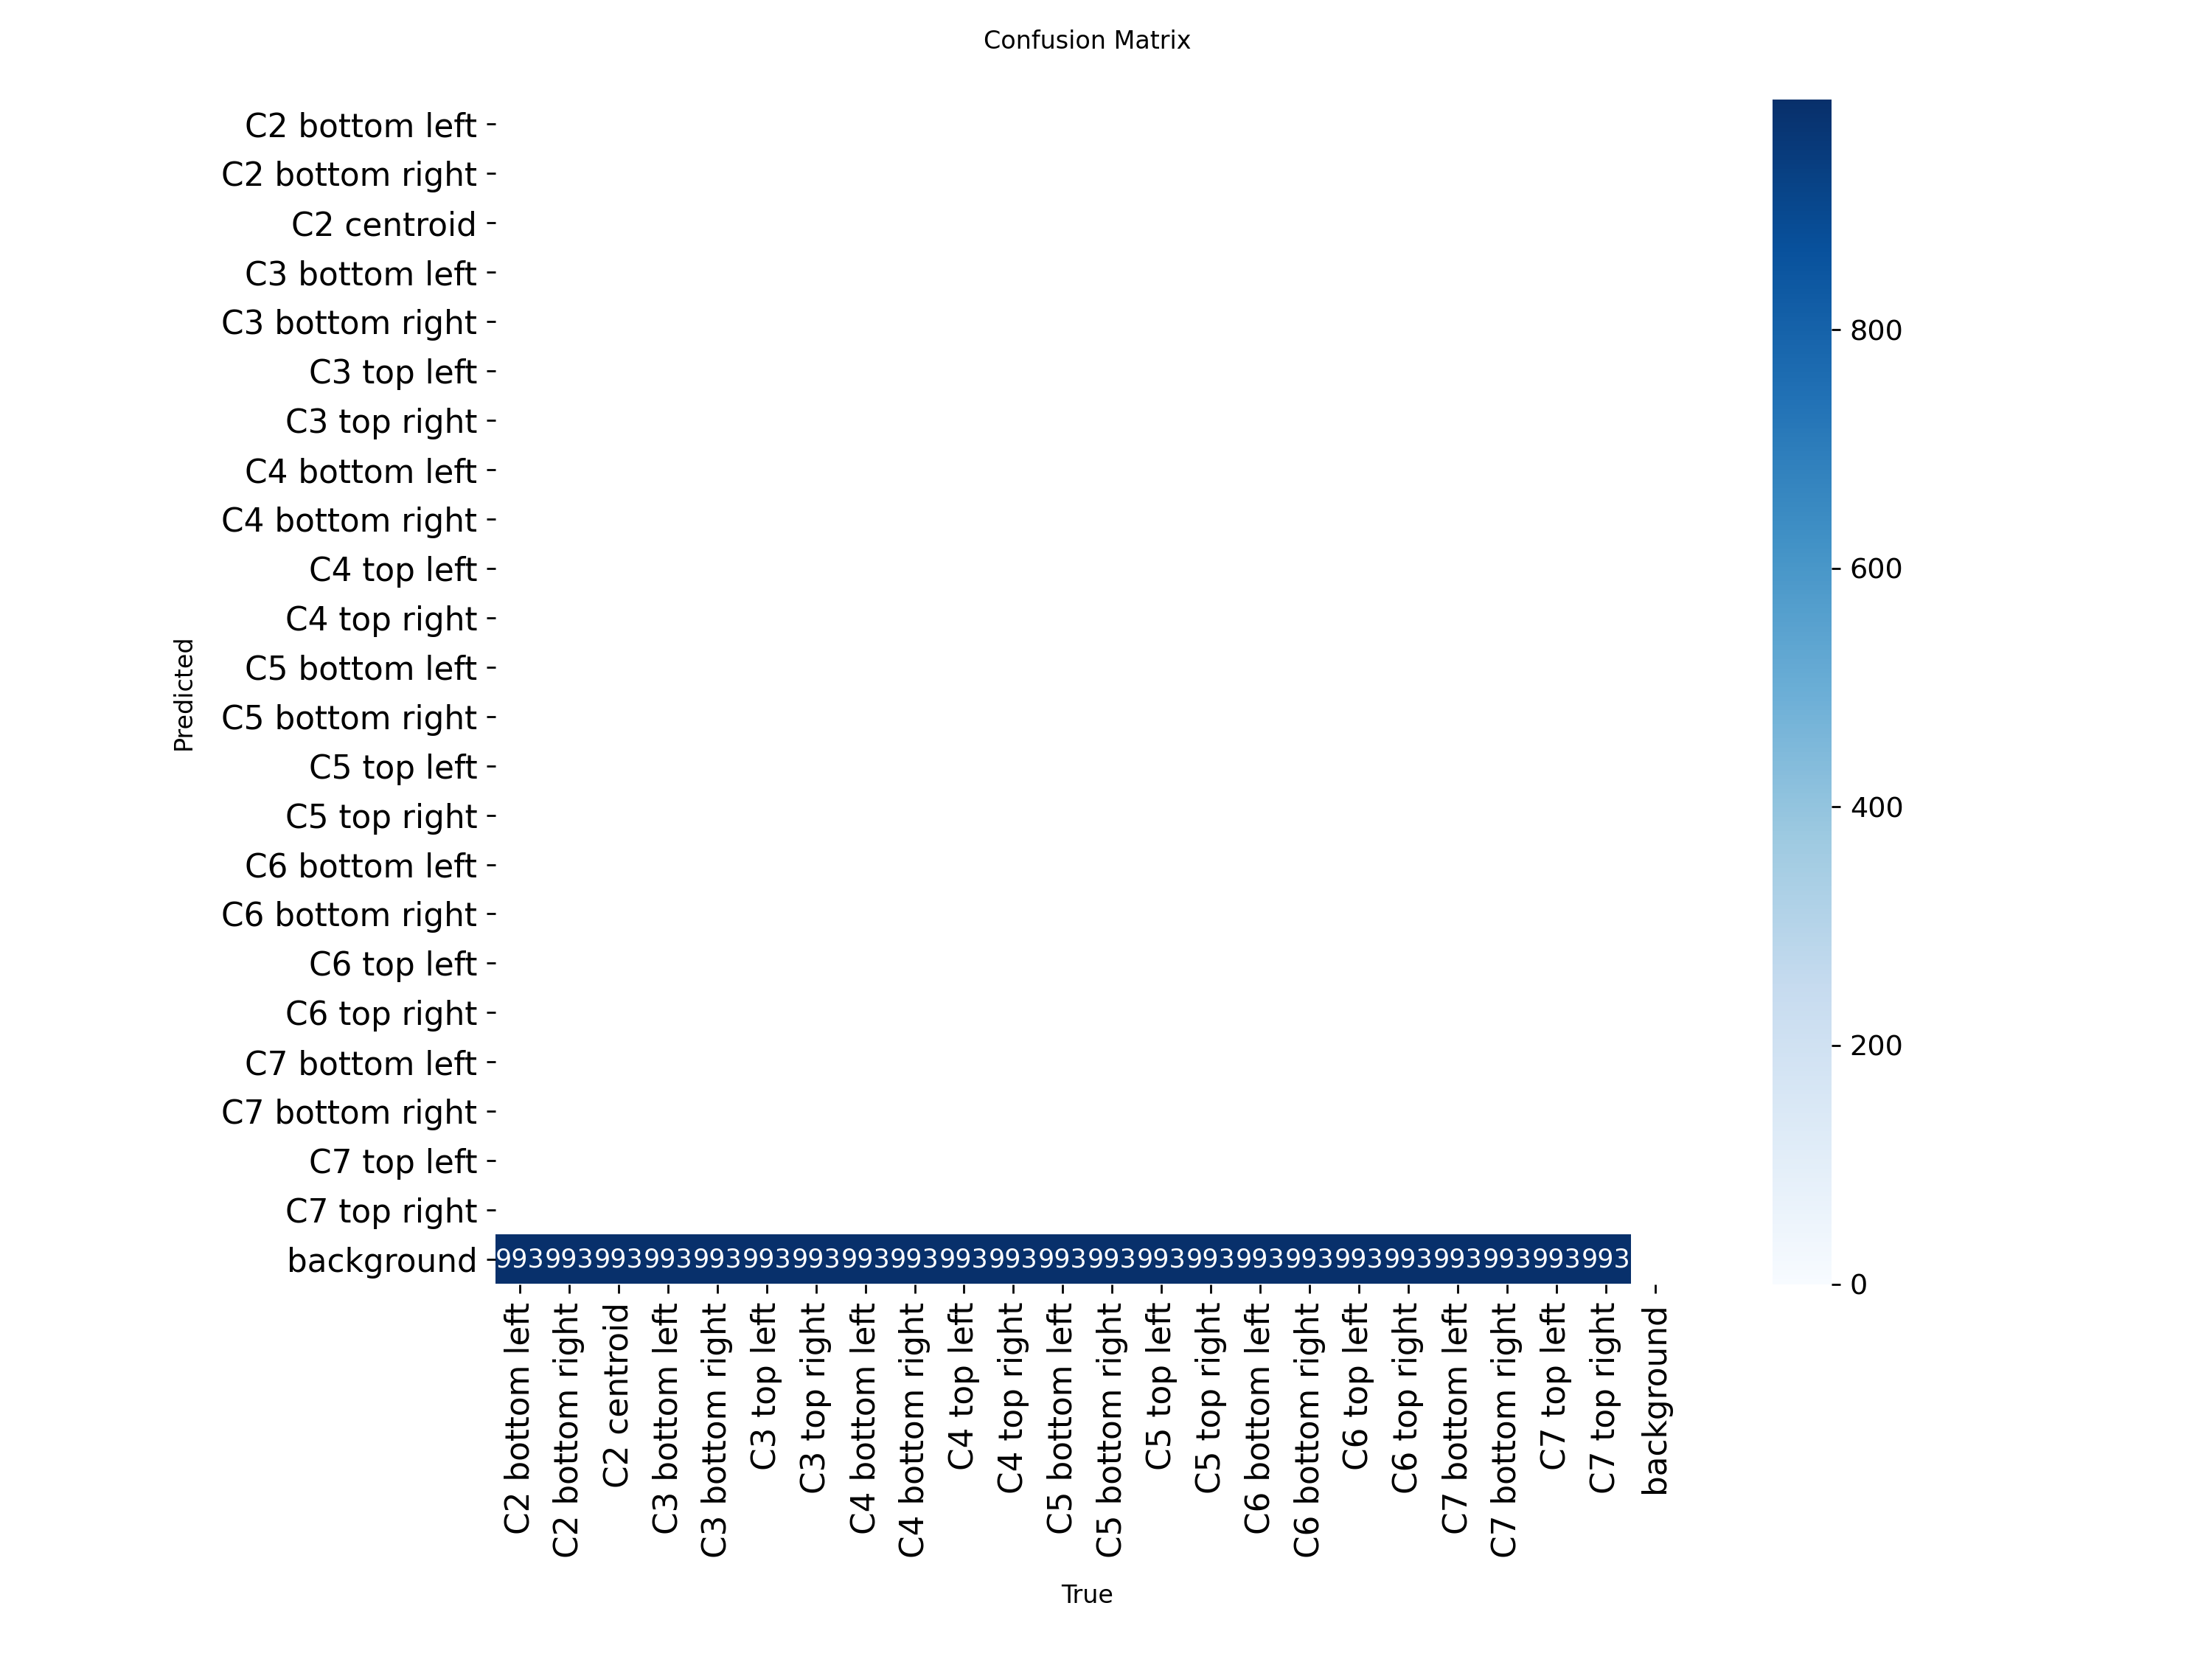

In [ ]:
%cd {HOME}

from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


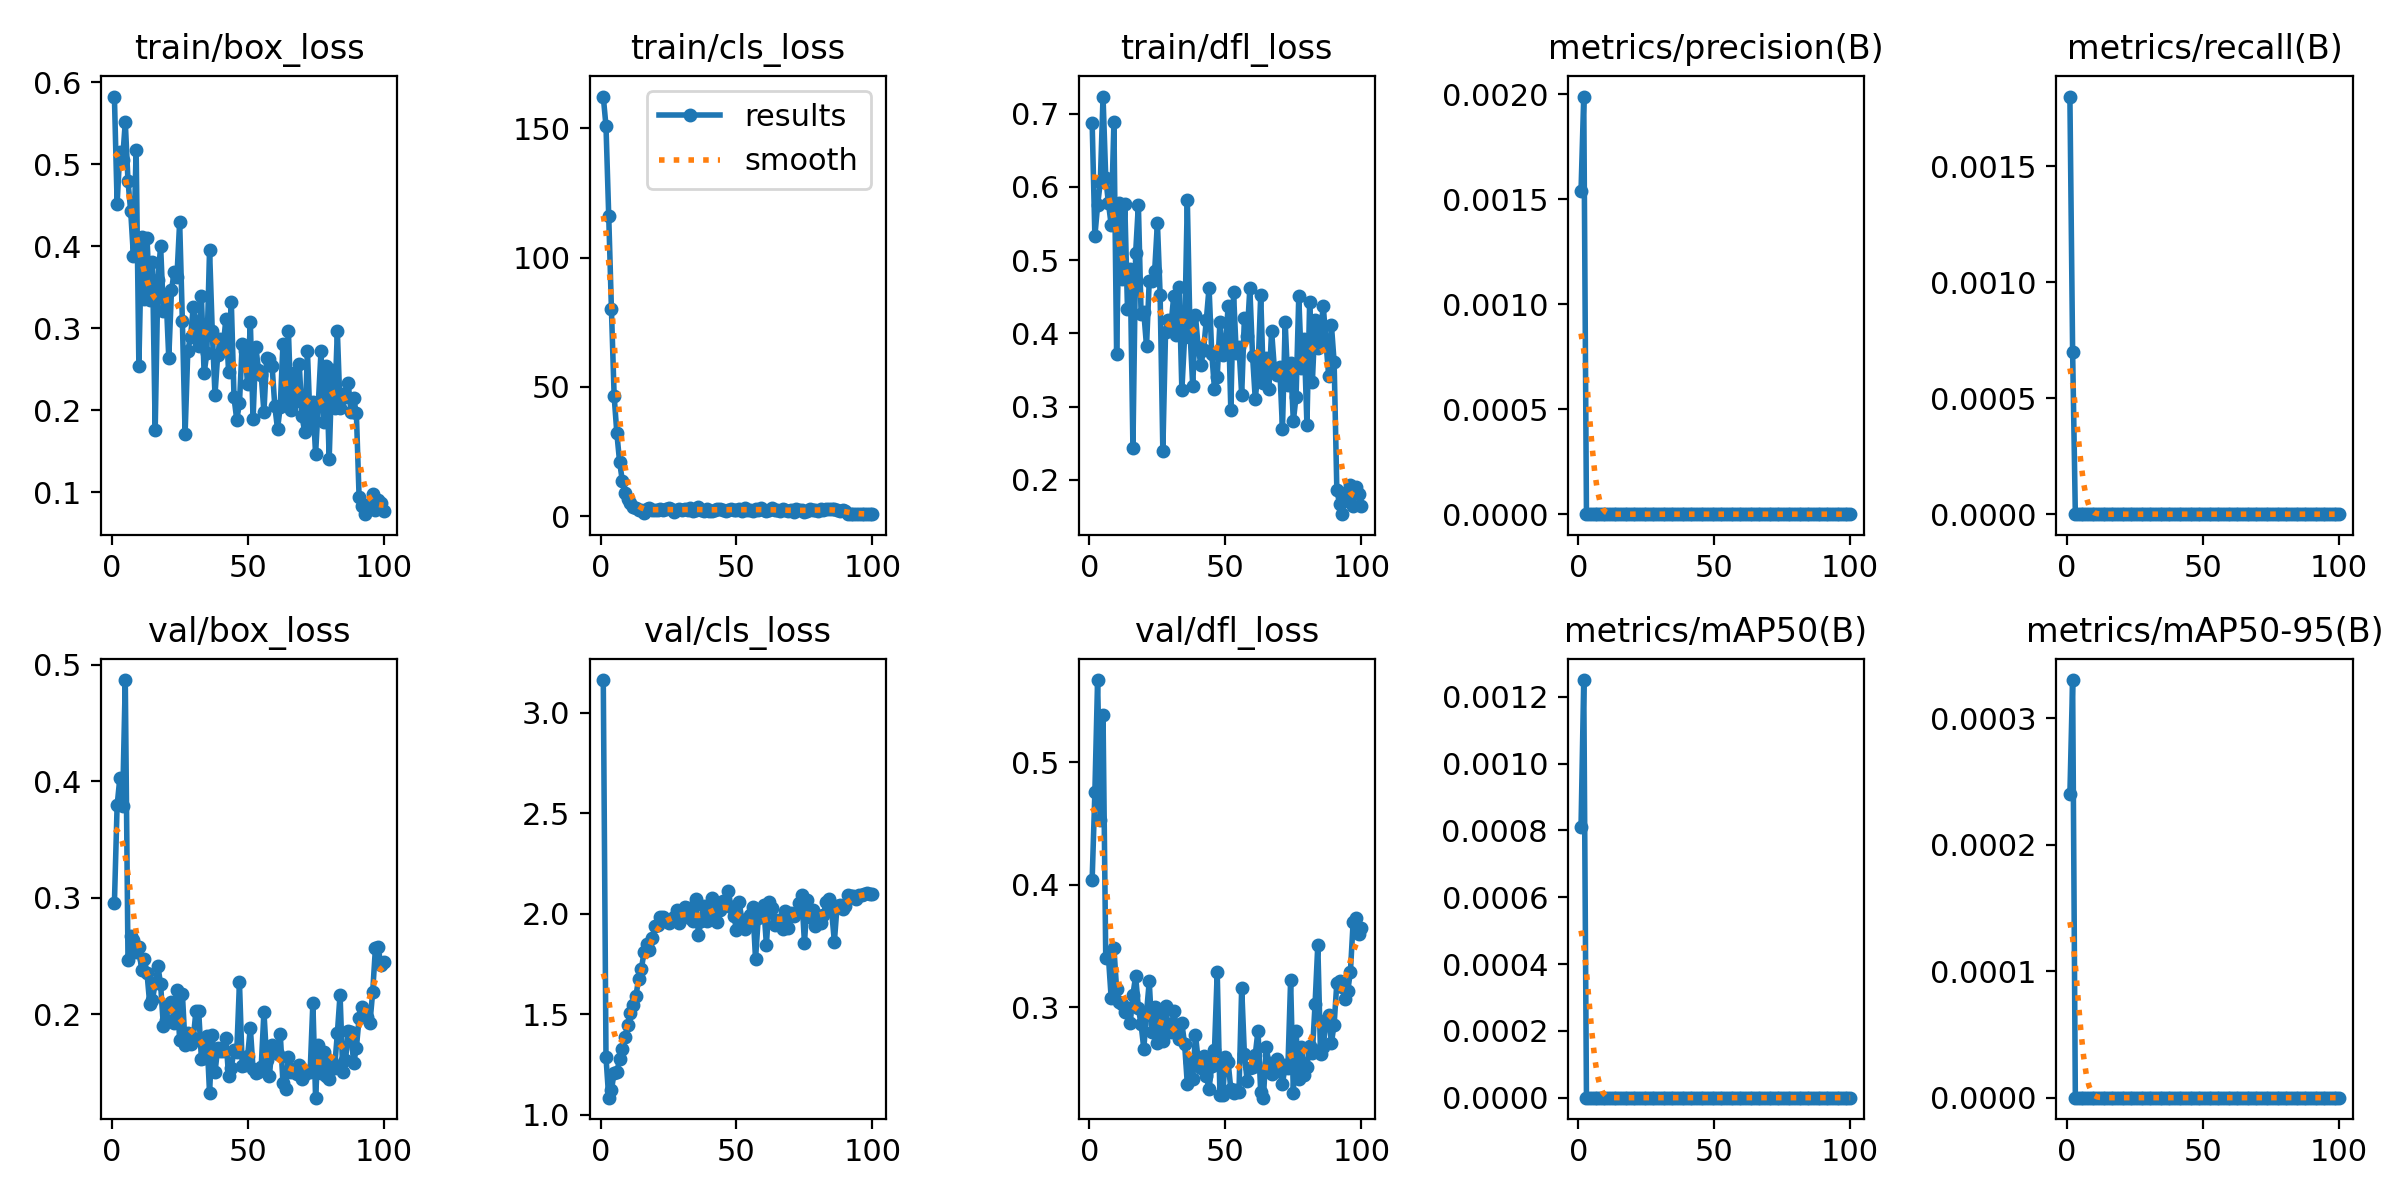

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

**NOTE:** Let's start by loading our newly trained model.

In [8]:
import cv2;
import matplotlib.pyplot as plt

image = cv2.imread('/content/drive/MyDrive/spine_abn_yolo_nologin/predict_images/000022_jpg.rf.cd7dbb58515643b36123199944316e1b.jpg')

In [9]:
!pip install ultralytics

from ultralytics import YOLO
import random

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Spinal Cord/best_SC_Segmentation.pt')
results = model(source=image, conf=0.25)


0: 640x640 18 texts, 9.9ms
Speed: 2.7ms preprocess, 9.9ms inference, 13.6ms postprocess per image at shape (1, 3, 640, 640)


In [10]:
results[0].boxes.xyxy

tensor([[232.9552, 428.9803, 268.2763, 455.2497],
        [230.9108, 352.6969, 264.1684, 378.7489],
        [252.7499, 236.1780, 279.8259, 257.0235],
        [230.7455, 391.8224, 264.6628, 418.3791],
        [255.0950, 140.0036, 279.7275, 158.1405],
        [256.7959, 116.8632, 281.0499, 133.5379],
        [248.2041, 261.5035, 276.6512, 283.8652],
        [257.6765,  93.8719, 281.3455, 110.1039],
        [234.5729, 318.7914, 267.8096, 344.0421],
        [255.3123, 164.9494, 279.1955, 181.9214],
        [257.9835,  71.1993, 280.0811,  86.7556],
        [255.8133, 212.2093, 280.2505, 229.4925],
        [255.9713, 188.9276, 279.8668, 205.2948],
        [257.7502,  50.0192, 278.2682,  64.2344],
        [240.4455, 288.0547, 272.9405, 313.8991],
        [234.6025, 466.1714, 274.7074, 492.5363],
        [257.3582,  28.8930, 277.9952,  43.1902],
        [257.8460,   7.7950, 278.8627,  21.7803]], device='cuda:0')


0: 640x640 18 texts, 8.4ms
Speed: 2.4ms preprocess, 8.4ms inference, 9.2ms postprocess per image at shape (1, 3, 640, 640)


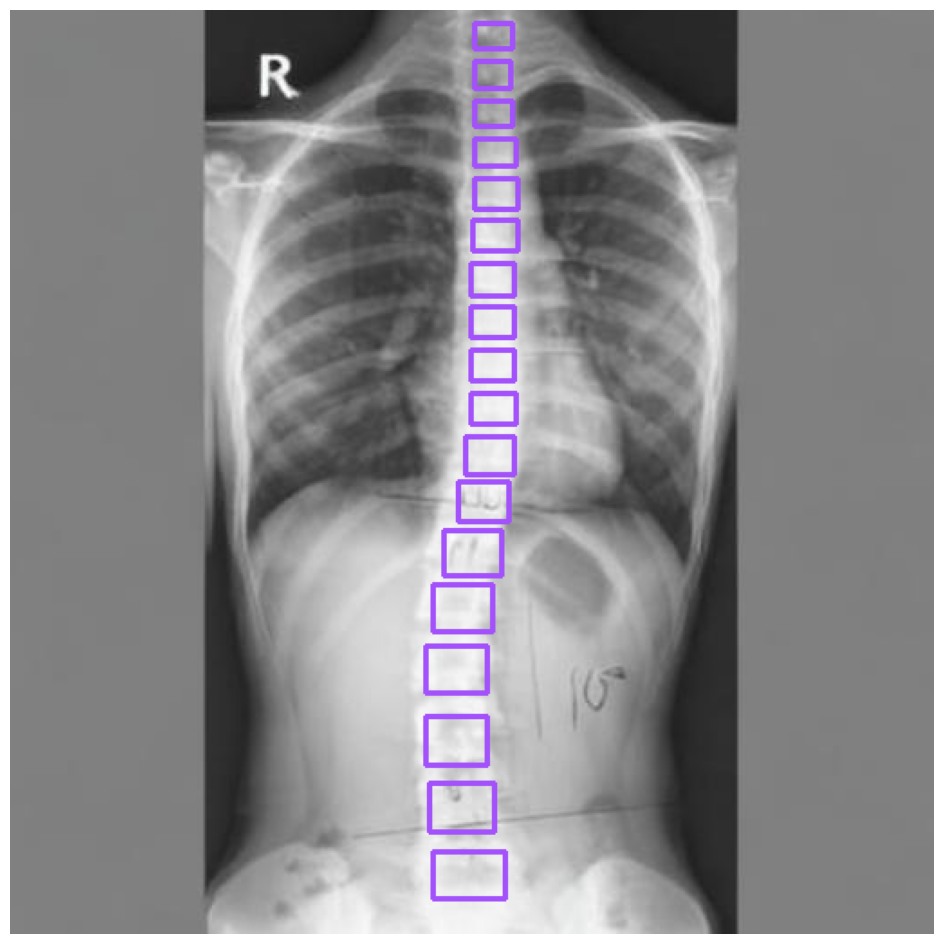

In [12]:
import cv2
import supervision as sv

model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Spinal Cord/best_SC_Segmentation.pt')
results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = box_annotator.annotate(
    scene=image, detections=detections)

sv.plot_image(annotated_image)

While your deployment is processing, checkout the deployment docs to take your model to most destinations https://docs.roboflow.com/inference

In [13]:
import os
import cv2
from ultralytics import YOLO
import supervision as sv

# Define input and output directories
input_dir = '/content/drive/MyDrive/spine_abn_yolo_nologin/predict_images/' # Assuming this is your folder with images
output_dir = '/content/drive/MyDrive/spine_abn_yolo_nologin/predictions_visual_CTL'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the best trained YOLO model (from previous training run)
# Make sure this path is correct if you trained a different model
model = YOLO('/content/drive/MyDrive/AI Dentistry - PHD Research/SAM/YOLO MODELS/Spinal Cord/best_SC_Segmentation.pt')

# Initialize annotators
box_annotator = sv.BoxAnnotator()
# label_annotator = sv.LabelAnnotator() # Uncomment if you want to add labels

# List all files in the input directory
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

print(f"Found {len(image_files)} images in '{input_dir}'")

if not image_files:
    print("No image files found in the input directory. Please check the path and file types.")
else:
    for image_name in image_files:
        image_path = os.path.join(input_dir, image_name)
        image = cv2.imread(image_path)

        if image is None:
            print(f"Warning: Could not load image {image_name}. Skipping.")
            continue

        print(f"Processing {image_name}...")

        # Perform detection
        results = model(image, verbose=False)[0]

        # Convert results to Supervision Detections format
        detections = sv.Detections.from_ultralytics(results)

        # Annotate the image with detected boxes
        annotated_image = box_annotator.annotate(
            scene=image.copy(), # Use .copy() to avoid modifying the original image directly
            detections=detections)
        # If you uncommented label_annotator, you can use it like this:
        # annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

        # Save the annotated image to the output directory
        output_image_path = os.path.join(output_dir, f"annotated_{image_name}")
        cv2.imwrite(output_image_path, annotated_image)

    print(f"\nAll processed images saved to '{output_dir}'")

Found 7 images in '/content/drive/MyDrive/spine_abn_yolo_nologin/predict_images/'
Processing 000623_jpg.rf.1e1e4b75396a8f3ab7a7a116662c53e9.jpg...
Processing 007748_jpg.rf.156d0b3f88e11038cfb41219a78f16cd.jpg...
Processing 007609_jpg.rf.f0af0be09ea6798c2a528c8e775bd90c.jpg...
Processing 007619_jpg.rf.ce7aa78c597d0a6bf6e15c08f4574777.jpg...
Processing 000675_jpg.rf.fe8d637068d3eb1eabcfab599d890328.jpg...
Processing 000022_jpg.rf.cd7dbb58515643b36123199944316e1b.jpg...
Processing 000123_jpg.rf.84dcd7bc30d7c6ae00c2671947ffc9b0.jpg...

All processed images saved to '/content/drive/MyDrive/spine_abn_yolo_nologin/predictions_visual_CTL'
